In [ ]:
# Mount into drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Change directory to the package folder
%cd '/content/drive/MyDrive/hateful_meme'

/content/drive/MyDrive/hateful_meme


In [ ]:
!pip install git+https://github.com/facebookresearch/mmf.git

  Cloning https://github.com/facebookresearch/mmf.git to /tmp/pip-req-build-yzk6o9y3
  Running command git clone -q https://github.com/facebookresearch/mmf.git /tmp/pip-req-build-yzk6o9y3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
  Cloning https://github.com/PyTorchLightning/pytorch-lightning (to revision 5b9995da0) to /tmp/pip-install-cof822qt/pytorch-lightning_2d30b3d1d0244ea5b35ef497deb44b23
  Running command git clone -q https://github.com/PyTorchLightning/pytorch-lightning /tmp/pip-install-cof822qt/pytorch-lightning_2d30b3d1d0244ea5b35ef497deb44b23
  Running command git checkout -q 5b9995da0
  Running command git submodule update --init --recursive -q
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done


In [ ]:
import torch
import torchvision
from PIL import Image
from mmf.common.sample import Sample, SampleList
from mmf.utils.general import get_current_device
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.autograd import Variable
import torch.nn.functional as F

In [ ]:
def get_transformed_image_tensor(img_path):
    image_transform = torchvision.transforms.Compose(
        [
            torchvision.transforms.Resize(size=(256, 256)),
            torchvision.transforms.CenterCrop(size=(224, 224)),
            torchvision.transforms.ToTensor()
        ]
    )
    actual_img = Image.open(img_path).convert("RGB")
    transformed_img = image_transform(actual_img)
    print(f'transformed_img size: {transformed_img.size()}')
    # with open(f'viz_{img_name}.png', 'w') as f:
    #     torchvision.utils.save_image(transformed_img, f)
    # torchvision.utils.save_image(transformed_img, f'viz_{img_name}.png')
    return transformed_img

In [ ]:
def get_sample_list(transformed_img):
    sample = Sample()
    sample.image = transformed_img
    sample_list = SampleList([sample])
    sample_list = sample_list.to(get_current_device())
    return sample_list


In [ ]:
def load_unimodal_image_model():
    # working
    from mmf.common.registry import registry
    model_cls = registry.get_model_class("unimodal_image")
    model = model_cls.from_pretrained("unimodal_image.hateful_memes.images")
    return model

In [ ]:
def create_dir_if_not_exists(dir_name):
    if not os.path.exists(dir_name):
        os.makedirs(dir_name)


In [ ]:
def plot_saliency_map(img_tensor, y, saliency, class_names, img_name):
    plt.imshow(img_tensor.permute(1, 2, 0))
    plt.axis('off')
    plt.title(class_names[y[0]])
    plt.imshow(saliency, cmap=plt.cm.gray)
    plt.axis('off')
    # plt.gcf().set_size_inches(12, 5)
    saliency_viz_dir = './saliency_map_viz'
    create_dir_if_not_exists(saliency_viz_dir)
    plt.savefig(f'{saliency_viz_dir}/custom_saliency_map_{img_name}.png')
    plt.show()

In [ ]:
def custom_saliency_map(img_name, img_path, label):
    img_tensor = get_transformed_image_tensor(img_path)
    X_var = Variable(img_tensor, requires_grad=True)
    x_sample_list = get_sample_list(X_var)

    y = np.array([label])
    y_tensor = torch.LongTensor(y)
    y_var = Variable(y_tensor, requires_grad=False)

    unimodal_model = load_unimodal_image_model()
    out = unimodal_model(x_sample_list)
    print(f'out: {out}')
    out_scores = out['scores']
    num_classes = out_scores.size()[1]
    print(f'num classes: {num_classes}')
    labels_one_hot = F.one_hot(y_var, num_classes=num_classes)
    print(f'labels_one_hot: {labels_one_hot}')
    scores_one_hot = out_scores * labels_one_hot
    print(f'scores_one_hot: {scores_one_hot}')
    total_score = torch.sum(scores_one_hot)
    total_score.backward()
    saliency_3_channels = torch.abs(X_var.grad)
    print(f'saliency_3_channels size: {saliency_3_channels.size()}')

    saliency = torch.max(saliency_3_channels, 0).values
    print(f'saliency: {saliency}')
    print(f'saliency size: {saliency.size()}')

    class_names = {
        0: 'Not Hateful',
        1: 'Hateful'
    }
    plot_saliency_map(img_tensor, y, saliency, class_names, img_name)

transformed_img size: torch.Size([3, 224, 224])
out: {'scores': tensor([[0.7155, 0.0334]], grad_fn=<AddmmBackward>)}
num classes: 2
labels_one_hot: tensor([[0, 1]])
scores_one_hot: tensor([[0.0000, 0.0334]], grad_fn=<MulBackward0>)
saliency_3_channels size: torch.Size([3, 224, 224])
saliency: tensor([[0.0014, 0.0017, 0.0014,  ..., 0.0014, 0.0001, 0.0003],
        [0.0018, 0.0027, 0.0011,  ..., 0.0008, 0.0005, 0.0002],
        [0.0035, 0.0024, 0.0035,  ..., 0.0005, 0.0018, 0.0023],
        ...,
        [0.0005, 0.0011, 0.0007,  ..., 0.0015, 0.0016, 0.0022],
        [0.0003, 0.0005, 0.0012,  ..., 0.0039, 0.0006, 0.0012],
        [0.0009, 0.0003, 0.0009,  ..., 0.0014, 0.0035, 0.0009]])
saliency size: torch.Size([224, 224])


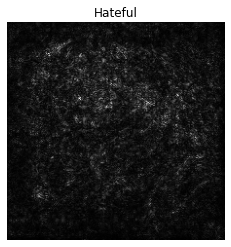

In [ ]:
if __name__ == '__main__':
    img_name = '98756'
    label = 1
    img_path = f'data/img/{img_name}.png'
    custom_saliency_map(img_name, img_path, label)